O presente código importa dados de simulações do modelo SIRS e gera diferentes gráficos úteis na análise dos dados gerados, como gráficos temporais da razão de infectados, mapas de calor, etc.

Importando as bibliotecas utilizadas:

In [46]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

Importando os dados no formato h5py e listando as simulações nele contidas:

In [47]:
arquivo_h5 = h5py.File('Simulações t0 x r0.h5', 'r')
simulacoes_disponiveis = list(arquivo_h5.keys()) # Cria uma lista com as chaves das simulações do arquivo
print(len(simulacoes_disponiveis))

8550


Parâmetros da simulação:

In [75]:
def parameters(grupo_simulacao):
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    mu = params.get('mu', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', 'N/A')
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    t_pico = params.get('t_pico', 'N/A')
    print(f'r0 = {r0}, mu = {mu}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}', 't_pico = {t_pico}')

In [76]:
arquivo_h5 = h5py.File('Simulações r0 =1.2 sem vacinacao.h5', 'r')
parameters(arquivo_h5['sim_0'])

r0 = 1.2, mu = 0.1, a = 0.0, n = 10000.0, delta = 0.005, vac_num = 0.7, t0 = 50, Tempo até atingir o estado estacionário = 2000.0, Motivo da parada = t_total, Probabilidade de Extinção = 0.0 t_pico = {t_pico}


/tmp/ipykernel_9668/2858530727.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  tf = t0 + vac_num/a


In [50]:
print(simulacoes_disponiveis)  # Exibe as simulações disponíveis

['sim_0', 'sim_1', 'sim_10', 'sim_100', 'sim_1000', 'sim_1001', 'sim_1002', 'sim_1003', 'sim_1004', 'sim_1005', 'sim_1006', 'sim_1007', 'sim_1008', 'sim_1009', 'sim_101', 'sim_1010', 'sim_1011', 'sim_1012', 'sim_1013', 'sim_1014', 'sim_1015', 'sim_1016', 'sim_1017', 'sim_1018', 'sim_1019', 'sim_102', 'sim_1020', 'sim_1021', 'sim_1022', 'sim_1023', 'sim_1024', 'sim_1025', 'sim_1026', 'sim_1027', 'sim_1028', 'sim_1029', 'sim_103', 'sim_1030', 'sim_1031', 'sim_1032', 'sim_1033', 'sim_1034', 'sim_1035', 'sim_1036', 'sim_1037', 'sim_1038', 'sim_1039', 'sim_104', 'sim_1040', 'sim_1041', 'sim_1042', 'sim_1043', 'sim_1044', 'sim_1045', 'sim_1046', 'sim_1047', 'sim_1048', 'sim_1049', 'sim_105', 'sim_1050', 'sim_1051', 'sim_1052', 'sim_1053', 'sim_1054', 'sim_1055', 'sim_1056', 'sim_1057', 'sim_1058', 'sim_1059', 'sim_106', 'sim_1060', 'sim_1061', 'sim_1062', 'sim_1063', 'sim_1064', 'sim_1065', 'sim_1066', 'sim_1067', 'sim_1068', 'sim_1069', 'sim_107', 'sim_1070', 'sim_1071', 'sim_1072', 'sim_10

Gráficos de Ixt com campanha de vacinação:

In [73]:
def ixt(grupo_simulacao, nome_arquivo_saida=None):
    # 1. Extrai os dados e parâmetros dos datasets
    tempo = grupo_simulacao['tempo'][:]
    I = grupo_simulacao['I'][:]
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    mu = params.get('mu', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', tempo[-1])
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    plt.figure(figsize=(12, 6))
    # 2. Plotando os gráficos:
    plt.plot(tempo, I, label='Infectados', color='blue')
    #plt.axvspan(t0, tf, color='lightblue', alpha=0.7, label="Campanha de vacinação")
    plt.title('Gráfico da Razão de Infectados no tempo no modelo SIRS')
    plt.grid()
    plt.xlabel('Tempo (dias)')
    plt.ylabel('Razão de Infectados I(t)')
    plt.legend(loc = 'upper right')
    print(f'r0 = {r0}, mu = {mu}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}')

r0 = 1.2, mu = 0.1, a = 0.0, n = 10000.0, delta = 0.005, vac_num = 0.7, t0 = 50, Tempo até atingir o estado estacionário = 2000.0, Motivo da parada = t_total, Probabilidade de Extinção = 0.0


/tmp/ipykernel_9668/1251730558.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  tf = t0 + vac_num/a


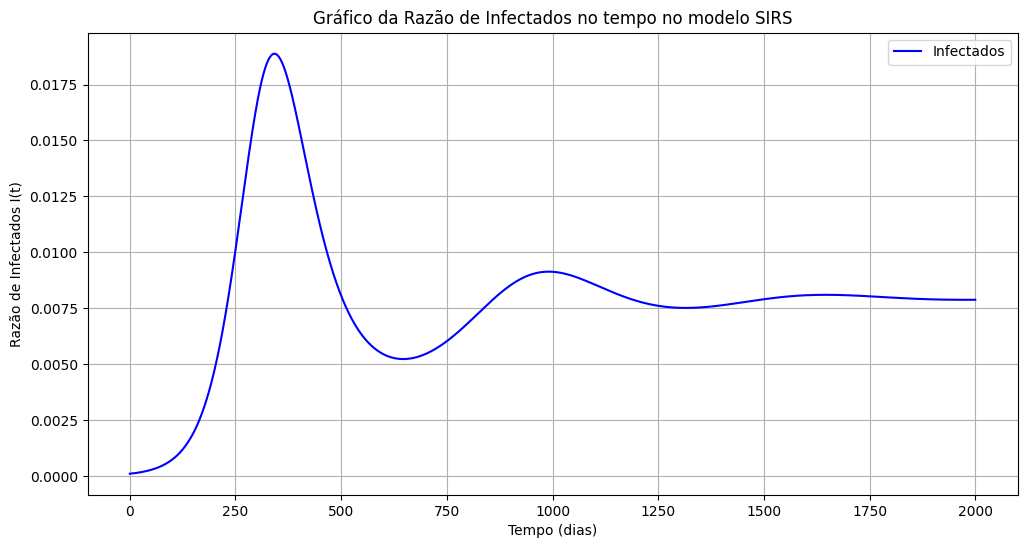

In [74]:
arquivo_h5 = h5py.File('Simulações r0 =1.2 sem vacinacao.h5', 'r')
ixt(arquivo_h5['sim_0'])   # Exemplo de uso da função com a primeira simulação

Gráficos de (S, I, R) x t com campanha de vacinação:

In [53]:
def sirxt(grupo_simulacao, nome_arquivo_saida=None):
    # 1. Extrai os dados e parâmetros dos datasets
    tempo = grupo_simulacao['tempo'][:]
    I = grupo_simulacao['I'][:]
    S = grupo_simulacao['S'][:]
    R = grupo_simulacao['R'][:]
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    mu = params.get('mu', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', tempo[-1])
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    # 2. Plotando os gráficos:
    plt.plot(tempo, I, label='Infectados', color='blue')
    plt.plot(tempo, S, label='Suscetíveis', color='red')
    plt.plot(tempo, R, label='Recuperados', color='orange')
    plt.axvspan(t0, tf, color='lightblue', alpha=0.7, label="Campanha de vacinação")
    plt.title('Gráfico da Razão de Infectados no tempo no modelo SIRS com vacinação')
    plt.grid()
    plt.xlabel('Tempo (dias)')
    plt.ylabel('Razão de Infectados I(t)')
    plt.legend(loc = 'upper right')
    print(f'r0 = {r0}, mu = {mu}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}')

In [54]:
print(simulacoes_disponiveis)  # Exibe as simulações disponíveis

['sim_0', 'sim_1', 'sim_10', 'sim_100', 'sim_1000', 'sim_1001', 'sim_1002', 'sim_1003', 'sim_1004', 'sim_1005', 'sim_1006', 'sim_1007', 'sim_1008', 'sim_1009', 'sim_101', 'sim_1010', 'sim_1011', 'sim_1012', 'sim_1013', 'sim_1014', 'sim_1015', 'sim_1016', 'sim_1017', 'sim_1018', 'sim_1019', 'sim_102', 'sim_1020', 'sim_1021', 'sim_1022', 'sim_1023', 'sim_1024', 'sim_1025', 'sim_1026', 'sim_1027', 'sim_1028', 'sim_1029', 'sim_103', 'sim_1030', 'sim_1031', 'sim_1032', 'sim_1033', 'sim_1034', 'sim_1035', 'sim_1036', 'sim_1037', 'sim_1038', 'sim_1039', 'sim_104', 'sim_1040', 'sim_1041', 'sim_1042', 'sim_1043', 'sim_1044', 'sim_1045', 'sim_1046', 'sim_1047', 'sim_1048', 'sim_1049', 'sim_105', 'sim_1050', 'sim_1051', 'sim_1052', 'sim_1053', 'sim_1054', 'sim_1055', 'sim_1056', 'sim_1057', 'sim_1058', 'sim_1059', 'sim_106', 'sim_1060', 'sim_1061', 'sim_1062', 'sim_1063', 'sim_1064', 'sim_1065', 'sim_1066', 'sim_1067', 'sim_1068', 'sim_1069', 'sim_107', 'sim_1070', 'sim_1071', 'sim_1072', 'sim_10

r0 = 1.2, mu = 0.1, a = 0.0, n = 10000.0, delta = 0.005, vac_num = 0.7, t0 = 50, Tempo até atingir o estado estacionário = 2000.0, Motivo da parada = t_total, Probabilidade de Extinção = 0.0


/tmp/ipykernel_9668/197556790.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  tf = t0 + vac_num/a


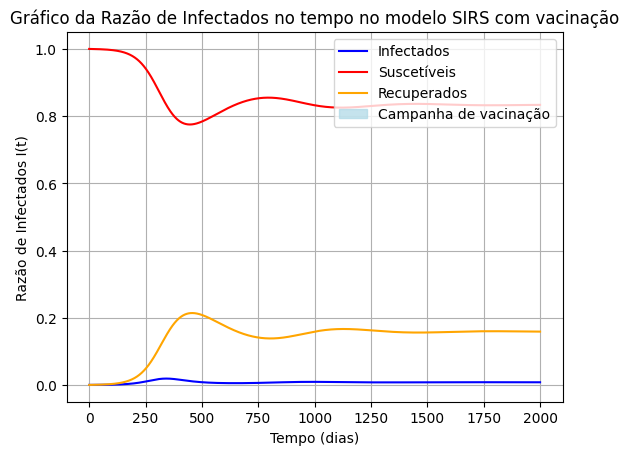

In [55]:
sirxt(arquivo_h5['sim_0']) 

Mapa de Calor: Probabilidade de Extinção em função de R0 e do número de vacinas para um conjunto fixo dos demais parâmetros

In [56]:
def r0xvac_num(arquivo, nome_arquivo_saida=None):
    dados = []
    for grupo_simulacao in arquivo.values():
        # 1. Extrai os dados e parâmetros dos datasets
        params = grupo_simulacao.attrs
        r0 = params.get('r0', 'N/A')
        prob_ext = params.get('prob_ext', 'N/A')
        vac_num = params.get('vac_num', 'N/A')
        # 2. Armazena os dados em uma lista de dicionários
        dados_simulacao = {
            'Basic Reprodution Number': r0,
            'Vaccines Number (Normalized)': vac_num,
            'Extinction Probability': prob_ext
        }
        dados.append(dados_simulacao)
    dados = pd.DataFrame(dados)

    x = dados['Basic Reprodution Number']
    y = dados['Vaccines Number (Normalized)']
    z = dados['Extinction Probability']
    x_unique = np.sort(x.unique())
    y_unique = np.sort(y.unique())
    # Criando uma matriz de zeros com dimensões baseadas em x e y
    Z = np.zeros((len(y_unique), len(x_unique)))
    # Preencher a matriz Z com os valores correspondentes
    for i, xi in enumerate(x_unique):
        for j, yj in enumerate(y_unique):
            mask = (x == xi) & (y == yj)
            if mask.any():
                Z[j, i] = dados.loc[mask, 'Extinction Probability'].mean()
    print(Z)
                # Criar o gráfico de mapa de calor
    plt.figure(figsize=(10, 6))
    plt.imshow(Z, aspect='auto', origin='lower', cmap='hot',
            extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)

    # Cor da barra de cor
    cbar = plt.colorbar(label="Extinction Probability")
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
    cbar.set_label("Extinction Probability", color='black')

    # Eixos e título em preto
    plt.xlabel('Basic Reprodution Number', color='black')
    plt.ylabel('Vaccines Number (Normalized)', color='black')
    plt.title("Extinction Probability: Basic Reprodution Number x Vaccines Number (Normalized)", color='black')

    # Ticks em preto
    plt.tick_params(axis='both', colors='black')
    plt.grid(False)
    plt.show()

/tmp/ipykernel_9668/4143928056.py:34: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(Z, aspect='auto', origin='lower', cmap='hot',
/tmp/ipykernel_9668/4143928056.py:34: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(Z, aspect='auto', origin='lower', cmap='hot',


[[0.]]


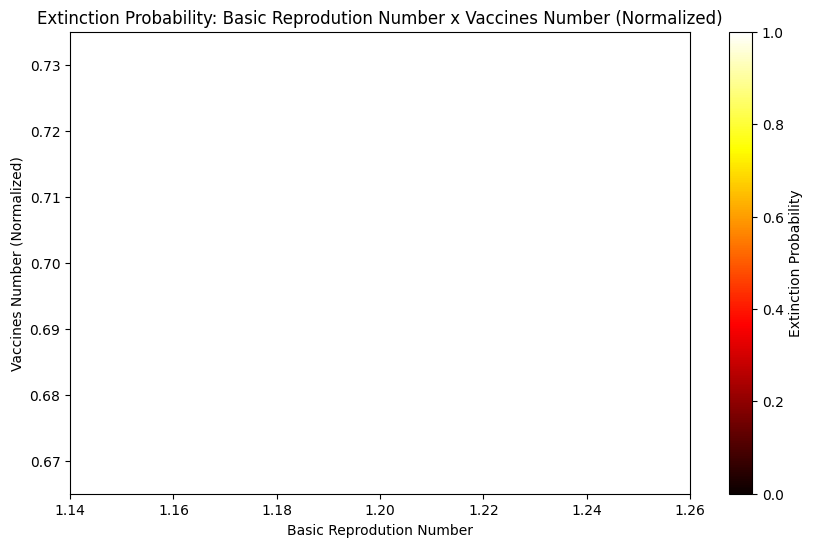

In [57]:
r0xvac_num(arquivo_h5)

Mapa de calor: Probabilidade de extinção para cada tempo de início da campanha de vacinação e de R0:

In [58]:
def t0xr0map(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupo_simulacao = f[key]
            params = grupo_simulacao.attrs
            r0 = params.get('r0', np.nan)
            t0 = params.get('t0', np.nan)
            prob_ext = params.get('prob_ext', np.nan)
            a = params.get('a', np.nan)
            vac_num = params.get('vac_num', np.nan)
            dados_simulacao = {
                'Basic Reprodution Number': r0,
                'Start Time of Vaccination Campaign': t0,
                'Extinction Probability': prob_ext,
                'Vaccination Rate': a,
                'Vaccines Number (Normalized)': vac_num
            }
            dados.append(dados_simulacao)
            df = pd.DataFrame(dados)

    x = df['Basic Reprodution Number']
    y = df['Start Time of Vaccination Campaign']
    z = df['Extinction Probability']
    x_unique = np.sort(x.unique())
    y_unique = np.sort(y.unique())
    # Criando uma matriz de zeros com dimensões baseadas em x e y
    Z = np.zeros((len(y_unique), len(x_unique)))
    # Preencher a matriz Z com os valores correspondentes
    for i, xi in enumerate(x_unique):
        for j, yj in enumerate(y_unique):
            mask = (x == xi) & (y == yj)
            if mask.any():
                Z[j, i] = df.loc[mask, 'Extinction Probability'].mean()
    print(Z)
                # Criar o gráfico de mapa de calor
    plt.figure(figsize=(10, 6))
    plt.imshow(Z, aspect='auto', origin='lower', cmap='hot',
            extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)

    # Cor da barra de cor
    cbar = plt.colorbar(label="Extinction Probability")
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
    cbar.set_label("Extinction Probability", color='black')

    # Eixos e título em preto
    plt.xlabel('Basic Reprodution Number', color='black')
    plt.ylabel('Start Time of Vaccination Campaign', color='black')
    plt.title("Extinction Probability: Basic Reprodution Number x Start Time of Vaccination Campaign", color='black')

    # Ticks em preto
    plt.tick_params(axis='both', colors='black')
    plt.grid(False)
    plt.show()

[[0.98972167 0.95711761 0.84138405 ... 0.         0.         0.        ]
 [0.98930725 0.955265   0.8349482  ... 0.         0.         0.        ]
 [0.98888182 0.95337728 0.82853729 ... 0.         0.         0.        ]
 ...
 [0.98472861 0.9739307  0.95515027 ... 0.         0.         0.        ]
 [0.9850408  0.97441622 0.955545   ... 0.         0.         0.        ]
 [0.9853435  0.97487351 0.95589055 ... 0.         0.         0.        ]]


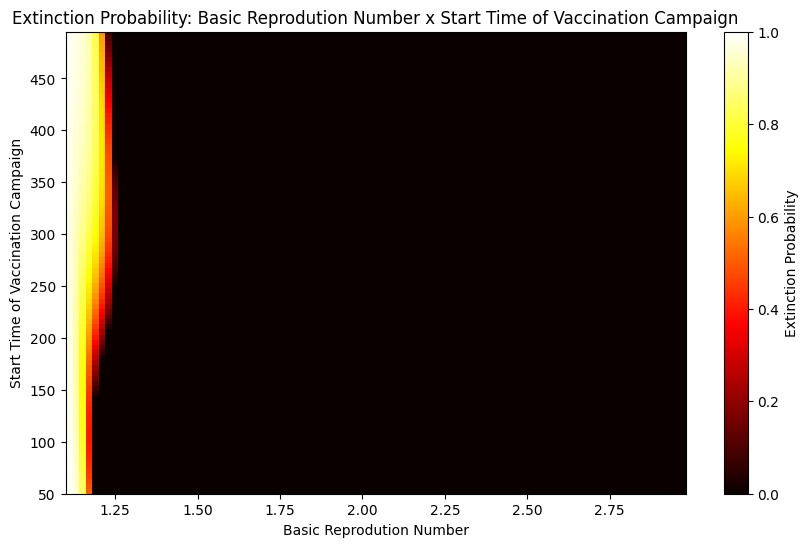

In [59]:
arquivo_h5 = h5py.File('Simulações t0 x r0.h5', 'r')
t0xr0map(arquivo_h5)

Gráfico do tempo ideal de aplicação da campanha de vacinação para cada valor de R0:
Neste gráfico busca-se encontrar para cada valor de R0 o momento do de início da camapanha que maximiza a probabilidade de extinção.
É interessante comparar tal gráfico com um gráfico do momento do pico x R0 no modelo SIRS sem vacinação para os mesmo parâmetros.

In [60]:
def t0xr0(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupo_simulacao = f[key]
            params = grupo_simulacao.attrs
            r0 = params.get('r0', np.nan)
            t0 = params.get('t0', np.nan)
            prob_ext = params.get('prob_ext', np.nan)
            a = params.get('a', np.nan)
            vac_num = params.get('vac_num', np.nan)
            dados_simulacao = {
                'r0': r0,
                't0': t0,
                'prob_ext': prob_ext,
                'a': a,
                'vac_num': vac_num
            }
            dados.append(dados_simulacao)
        df_completo = pd.DataFrame(dados)
        idx_max_prob = df_completo.groupby('r0')['prob_ext'].idxmax()
        df_otimo = df_completo.loc[idx_max_prob]
    plt.figure(figsize=(10, 6))

    plt.scatter(df_otimo['r0'], df_otimo['t0'], c=df_otimo['prob_ext'], cmap='viridis', s=40, edgecolor='black', vmin=0, vmax=1)
    cbar = plt.colorbar()
    cbar.set_label('Probabilidade de Extinção Máxima')
    plt.xlabel('Número de Reprodução Básico (R0)')
    plt.ylabel('t0 Ótimo (início da camapanha)')
    plt.title('Data de início da campanha que maximiza a Probabilidade de Extinção para cada R0')
    plt.grid()
    plt.show()

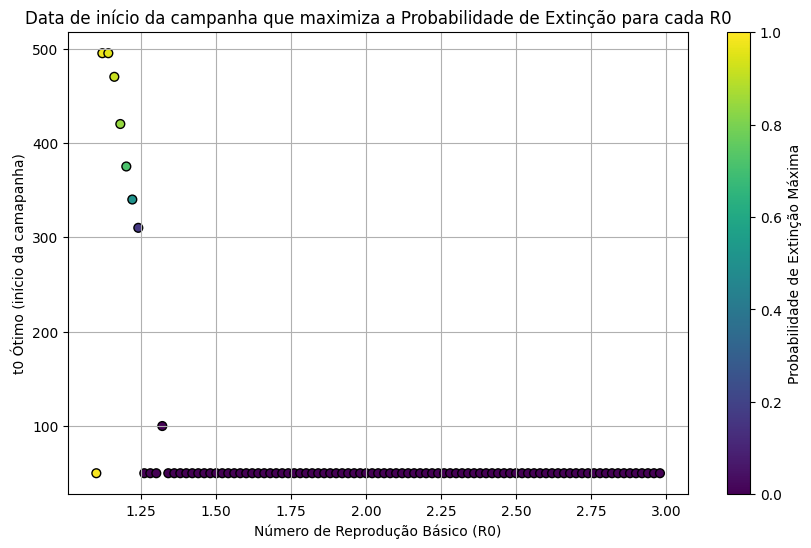

In [61]:
arquivo_h5 = h5py.File('Simulações t0 x r0.h5', 'r')
t0xr0(arquivo_h5)

Gráfico do momento do pico x R0 no modelo SIRS sem vacinação:

In [62]:
def picoxr0(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupo_simulacao = f[key]
            params = grupo_simulacao.attrs
            tempo = grupo_simulacao['tempo'][:]
            I = grupo_simulacao['I'][:]
            indice_do_pico = np.argmax(I)
            t_pico = tempo[indice_do_pico]
            r0 = params.get('r0', 'N/A')
            dados = []
            dados_simulacao = {
                'r0': r0,
                't_pico': t_pico
            }
            dados.append(dados_simulacao)
            dados = pd.DataFrame(dados)
    plt.figure(figsize=(10, 6))
    plt.scatter(dados['r0'], dados['t_pico'], color='blue', edgecolor='black', s=100)
    plt.xlabel('Número de Reprodução Básico (R0)')
    plt.ylabel('Tempo até o Pico de Infectados (dias)')
    plt.title('Tempo até o Pico de Infectados em função do R0')
    plt.grid()
    plt.show()

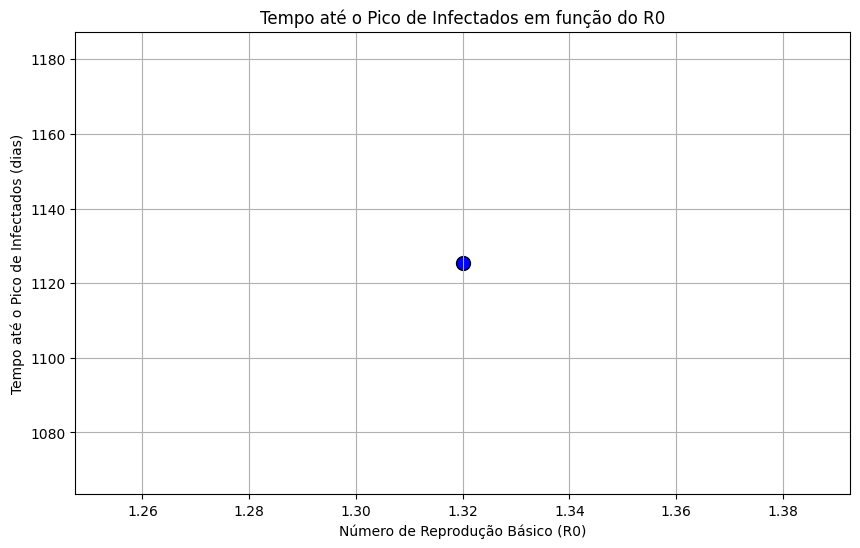

In [63]:
arquivo_h5 = h5py.File('Simulações t0 x r0.h5', 'r')
picoxr0(arquivo_h5)

Probabilidade de extinção x t0:

In [ ]:
def probextxt0(arquivo, nome_arquivo_saida=None):
    dados = []
    with arquivo as f:
        for key in f.keys():
            grupos_r0 = []
            grupo_simulacao = f[key]
            if np.isclose(grupo_simulacao.attrs.get('r0', np.nan), 1.2):
                grupos_r0.append(grupo_simulacao)
                params = grupo_simulacao.attrs
                t0 = params.get('t0', np.nan)
                prob_ext = params.get('prob_ext', np.nan)
                r0 = params.get('r0', np.nan)
                dados_simulacao = {
                    't0': t0,
                    'prob_ext': prob_ext,
                    'r0' : r0
                }
                dados.append(dados_simulacao)
        df = pd.DataFrame(dados)
    print(df.loc[df['prob_ext'].idxmax(), 't0'])
    plt.figure(figsize=(12, 6))

    plt.scatter(df['t0'], df['prob_ext'], label = 'Probabilidade de Extinção', color='black', edgecolor='black', s=5)
    plt.xlabel('Momento de início da campanha (t0)')
    plt.ylim(-0.1, 1.1)
    plt.ylabel('Probabilidade de Extinção')
    plt.title('Probabilidade de Extinção x Momento de início da campanha')
    plt.grid()
    plt.show()

376


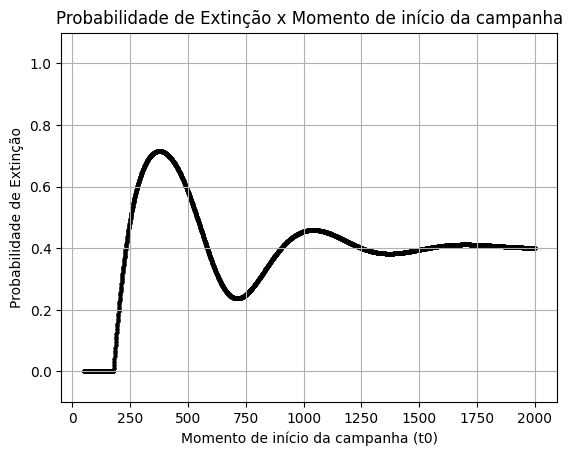

In [ ]:
arquivo_h5 = h5py.File('Simulações prob_ext x t0 r0 =1.2.h5', 'r')
probextxt0(arquivo_h5)